<a href="https://colab.research.google.com/github/Abraheem2010/Image-Processing-Assignments/blob/main/Assignment-3-Binary-Images/solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/dnevo/ImageProcessing/blob/main/ImageProcessingEx_03_BinaryImages.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Processing Assignment 3: Binary images

Before we start, please put your names and IDs in following format

: Firstname LASTNAME, #00000000   //   (e.g.) Dana LEVI, #12345678

**Your Answer:**   
אברהים חסדייה

In this exercise, you will implement **Binary Images** algorithms.

Methods: as explained in class.

Notes:
*   Write your code in the dedicated areas (TODO blocks). You can add helper functions.
*   Submission email should include a link to the Colab submission notebook located on your Google Drive with Commenter access right to nev1958a@gmail.com
*   The solution notebook should be able to be run (‘Run all’) with no errors.
In case of errors, the submission will be disqualified.
*   The grade will depend on correct performance on several grayscale images and on clean programming and documentation.
*   Do not forget to add the Names and Student I.D. at the top of the notebook.
*   All images are given as 2-dimensional matrices of type `float`, with values in the range [0..1].
*   Pay Attention! In the following functions, the returned images must be the same size as the original Images!

Please implement the following functions:
1. Write the `tag_connected_components` function which finds the connected components in a binary image and returns a matrix with the same size in which each connected component is tagged with a different label. The tags should be sequential.
2. Write the `skeletonizeImage` function which skeletonizes objects in a given binary image and returns the new binary image.

**Note** In these images, **1** represents the object, and **0** (black) represents the background.

## Setup Code
Before getting started, we need to run some boilerplate code to set up our environment. You will need to rerun this setup code each time you start the notebook.

In [17]:
import os
import urllib.request
from io import BytesIO
import numpy as np
import matplotlib.pyplot as plt
import PIL

In [18]:
GITHUB_PATH = 'https://raw.githubusercontent.com/dnevo/ImageProcessing/main/images/'

In [19]:
def read_file(file_name:str, file_path:str=GITHUB_PATH) -> np.ndarray:
    '''
    Accept an image file name (defaulty located in GitHub) and return the image
    in a numpy array.

    Args:
        file_name: the file name
        file_path: the file path.. Default value is Doron's Github repo.

    Returns:
        the image converted into a Numpy array.
    '''
    if file_path.startswith('http://') or file_path.startswith('https://'):
        if not file_path.endswith('/'):
            file_path = file_path + '/'
        with urllib.request.urlopen(file_path + file_name, timeout=30) as response:
            fp = BytesIO(response.read())
        img_pil = PIL.Image.open(fp)
    else:
        img_pil = PIL.Image.open(os.path.join(file_path, file_name))
    return np.array(img_pil, dtype='int16')

In [20]:
def pretty_print(img):
    ''' pretty printing of binary imagees and connected components - by
    replacing zeros with whitespaces.
    Args:
        img: image in float format (range: 0..1) - the source binary image
        file_path: the file path.. Default value is Doron's Github repo.

    Returns:
        the image converted into a Numpy array.
    '''
    for r in range(img.shape[0]):
        l = [str(img[r,c].astype(np.int16)) if img[r,c]>0 else ' ' for c in range(img.shape[1])]
        print(''.join(map(str, l)))

In [21]:
def plot_images(img1:np.array, img2:np.array):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))
    axes[0].imshow(img1,  cmap='gray')
    axes[1].imshow(img2,  cmap='gray')

## `tag_connected_components`

In [22]:
# ---------------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------------
def _validate_binary_image(img: np.array) -> np.ndarray:
    # Coerce to float, require a 2-D matrix, and threshold to a 0/1 array.
    img = np.asarray(img, dtype=np.float64)
    if img.ndim != 2:
        raise ValueError('Binary image must be a 2-dimensional matrix.')
    return (img > 0).astype(np.uint8)


def _connected_neighbors(row: int, col: int, rows: int, cols: int):
    # Yield the in-bounds 4-connected neighbours (up, down, left, right).
    for dr, dc in ((-1, 0), (1, 0), (0, -1), (0, 1)):
        new_row = row + dr
        new_col = col + dc
        if 0 <= new_row < rows and 0 <= new_col < cols:
            yield new_row, new_col


def tag_connected_components(img: np.array) -> np.array:
    '''
    This function receives a binary image and finds the connected components
    in it and returns a matrix with the same size in which each connected
    componnent is tagged with a different label. The tags should be sequential.

    Args:
        img: image in float format (range: 0..1) - the source binary image

    Returns:
        img_new: in float format - the image with components tagging in a
        2-dimensional matrice
    '''
    ######################################################################
    # TODO: Implement The tag connected components algorithm.
    ######################################################################
    # Binarize the input and start an all-zero label map (0 = background).
    binary_img = _validate_binary_image(img)
    rows, cols = binary_img.shape
    img_new = np.zeros((rows, cols), dtype=np.float64)
    current_label = 1

    # Raster scan: every unlabeled foreground pixel seeds a new component.
    for row in range(rows):
        for col in range(cols):
            if binary_img[row, col] == 0 or img_new[row, col] != 0:
                continue

            # Flood-fill the component with an iterative DFS (explicit stack).
            stack = [(row, col)]
            img_new[row, col] = current_label

            while stack:
                current_row, current_col = stack.pop()
                for neighbor_row, neighbor_col in _connected_neighbors(current_row, current_col, rows, cols):
                    if binary_img[neighbor_row, neighbor_col] == 1 and img_new[neighbor_row, neighbor_col] == 0:
                        img_new[neighbor_row, neighbor_col] = current_label
                        stack.append((neighbor_row, neighbor_col))

            # Component finished - advance to the next sequential label.
            current_label += 1
    ######################################################################
    #                            END OF YOUR CODE                        #
    ######################################################################

    return img_new

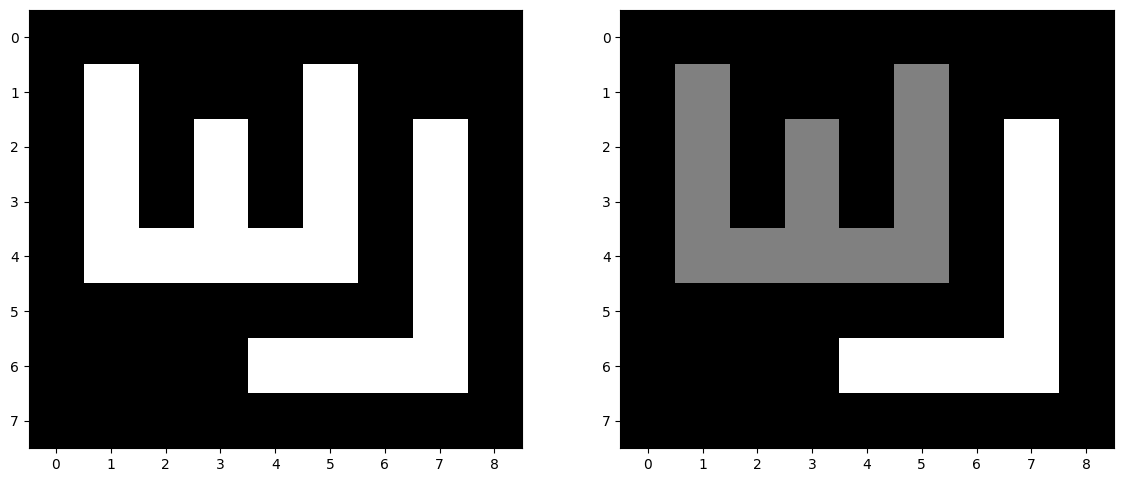

In [23]:
img = np.array([[0,0,0,0,0,0,0,0,0],
       [0,1,0,0,0,1,0,0,0],
       [0,1,0,1,0,1,0,1,0],
       [0,1,0,1,0,1,0,1,0],
       [0,1,1,1,1,1,0,1,0],
       [0,0,0,0,0,0,0,1,0],
       [0,0,0,0,1,1,1,1,0],
       [0,0,0,0,0,0,0,0,0]])
img_n = tag_connected_components(img)
plot_images(img, img_n)

In [24]:
pretty_print(img_n)

         
 1   1   
 1 1 1 2 
 1 1 1 2 
 11111 2 
       2 
    2222 
         


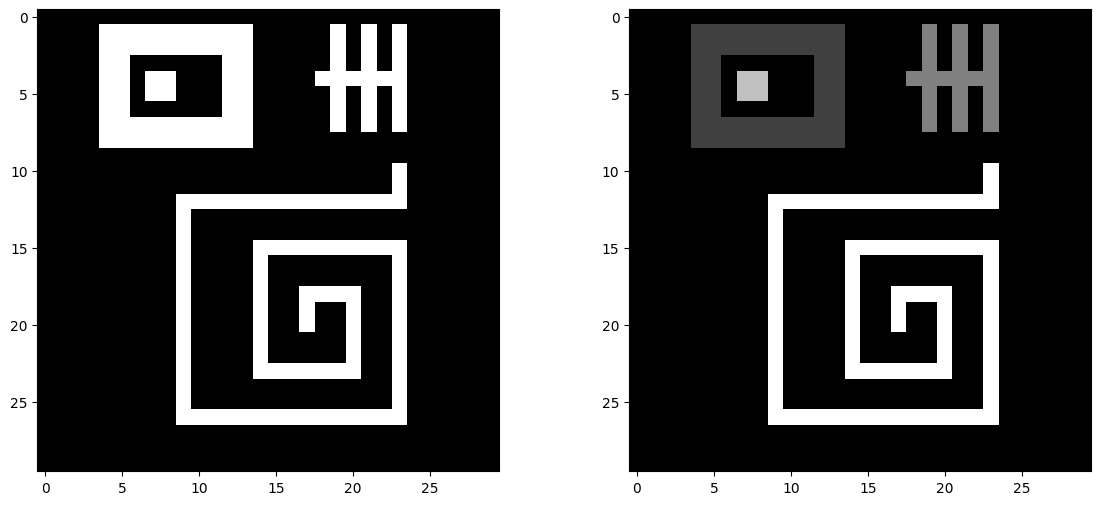

In [25]:
img = read_file('binary1.tiff') / 255
img_n = tag_connected_components(img)
plot_images(img, img_n)

In [26]:
pretty_print(img_n)

                              
    1111111111     2 2 2      
    1111111111     2 2 2      
    11      11     2 2 2      
    11 33   11    222222      
    11 33   11     2 2 2      
    11      11     2 2 2      
    1111111111     2 2 2      
    1111111111                
                              
                       4      
                       4      
         444444444444444      
         4                    
         4                    
         4    4444444444      
         4    4        4      
         4    4        4      
         4    4  4444  4      
         4    4  4  4  4      
         4    4  4  4  4      
         4    4     4  4      
         4    4     4  4      
         4    4444444  4      
         4             4      
         4             4      
         444444444444444      
                              
                              
                              


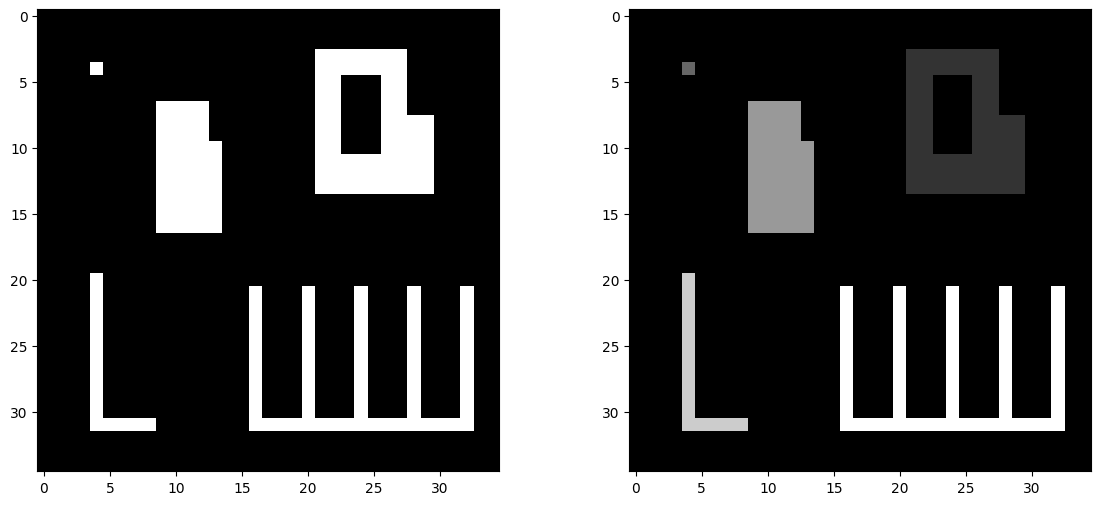

In [27]:
img = read_file('binary2.tiff') / 255
img_n = tag_connected_components(img)
plot_images(img, img_n)

In [28]:
pretty_print(img_n)

                                   
                                   
                                   
                     1111111       
    2                1111111       
                     11   11       
                     11   11       
         3333        11   11       
         3333        11   1111     
         3333        11   1111     
         33333       11   1111     
         33333       111111111     
         33333       111111111     
         33333       111111111     
         33333                     
         33333                     
         33333                     
                                   
                                   
                                   
    4                              
    4           5   5   5   5   5  
    4           5   5   5   5   5  
    4           5   5   5   5   5  
    4           5   5   5   5   5  
    4           5   5   5   5   5  
    4           5   5   5   5   5  
    4           5   5   5   

## `skeletonizeImage `

In [29]:
# ---------------------------------------------------------------------------
# Morphological primitives (3x3 cross / plus-shaped structuring element)
# ---------------------------------------------------------------------------
def _erode_cross(img: np.ndarray) -> np.ndarray:
    '''Erode binary image with 3x3 cross structuring element.'''
    result = np.zeros_like(img)
    rows, cols = img.shape
    # A pixel survives erosion only if it and all 4 cross-neighbours are set.
    for r in range(1, rows - 1):
        for c in range(1, cols - 1):
            if img[r, c] == 1 and img[r-1, c] == 1 and img[r+1, c] == 1 and img[r, c-1] == 1 and img[r, c+1] == 1:
                result[r, c] = 1
    return result


def _dilate_cross(img: np.ndarray) -> np.ndarray:
    '''Dilate binary image with 3x3 cross structuring element.'''
    result = np.zeros_like(img)
    rows, cols = img.shape
    # Dilation: each set pixel turns on itself and its 4 cross-neighbours.
    for r in range(rows):
        for c in range(cols):
            if img[r, c] == 1:
                result[r, c] = 1
                if r > 0: result[r-1, c] = 1
                if r < rows - 1: result[r+1, c] = 1
                if c > 0: result[r, c-1] = 1
                if c < cols - 1: result[r, c+1] = 1
    return result


def _open_morph(img: np.ndarray) -> np.ndarray:
    '''Morphological opening = erosion followed by dilation.'''
    return _dilate_cross(_erode_cross(img))


def skeletonizeImage (img: np.array) -> np.array:
    '''
    This function receives a binary image and finds the connected components
    in it and returns a new binary image with skeletonize objects.

    Args:
        img: image in float format (range: 0..1) - the source binary image

    Returns:
        img_new: in float format (range: 0..1) - the image with skeleton
                    in a 2 dimensional matrice.
    '''
    ######################################################################
    # TODO: Implement The skeletonize algorithm.
    ######################################################################
    # Morphological skeleton via iterative erosion + opening differences:
    # skeleton = union over each erosion scale of (A - opening(A)).
    binary_img = _validate_binary_image(img)
    skeleton = np.zeros_like(binary_img)
    A = binary_img.copy()

    # Iterate, peeling one layer per step, until the object vanishes.
    while np.any(A):
        eroded = _erode_cross(A)
        opened = _open_morph(A)
        # Skeleton subset at this scale: pixels removed by the opening.
        sk = ((A - opened) > 0).astype(np.uint8)
        skeleton = ((skeleton + sk) > 0).astype(np.uint8)
        # Erode by one layer for the next scale.
        A = eroded

    img_new = skeleton.astype(np.float64)
    ######################################################################
    #                            END OF YOUR CODE                        #
    ######################################################################
    return img_new

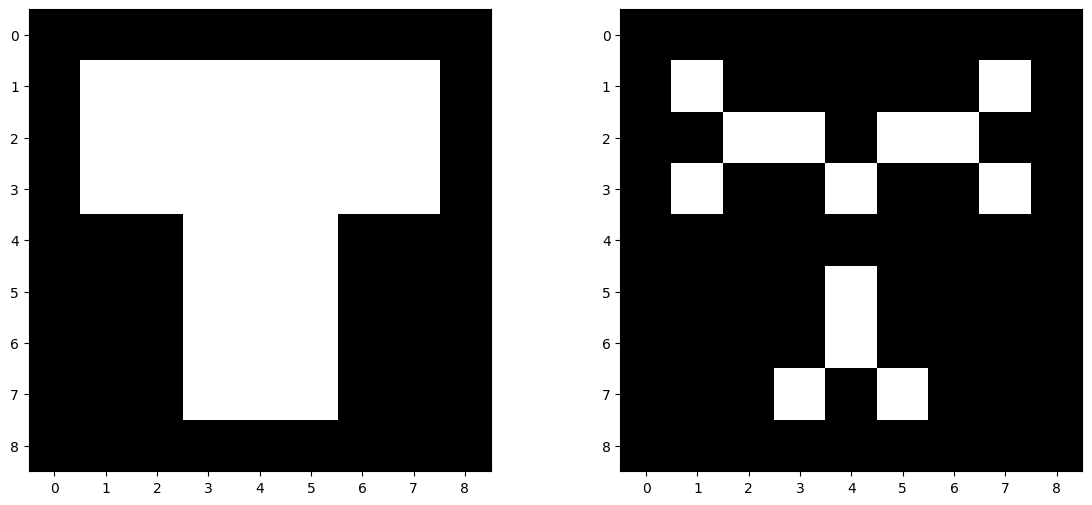

In [30]:
img = np.array([[0,0,0,0,0,0,0,0,0],
                [0,1,1,1,1,1,1,1,0],
                [0,1,1,1,1,1,1,1,0],
                [0,1,1,1,1,1,1,1,0],
                [0,0,0,1,1,1,0,0,0],
                [0,0,0,1,1,1,0,0,0],
                [0,0,0,1,1,1,0,0,0],
                [0,0,0,1,1,1,0,0,0],
                [0,0,0,0,0,0,0,0,0]])
img_new = skeletonizeImage(img)
plot_images(img, img_new)

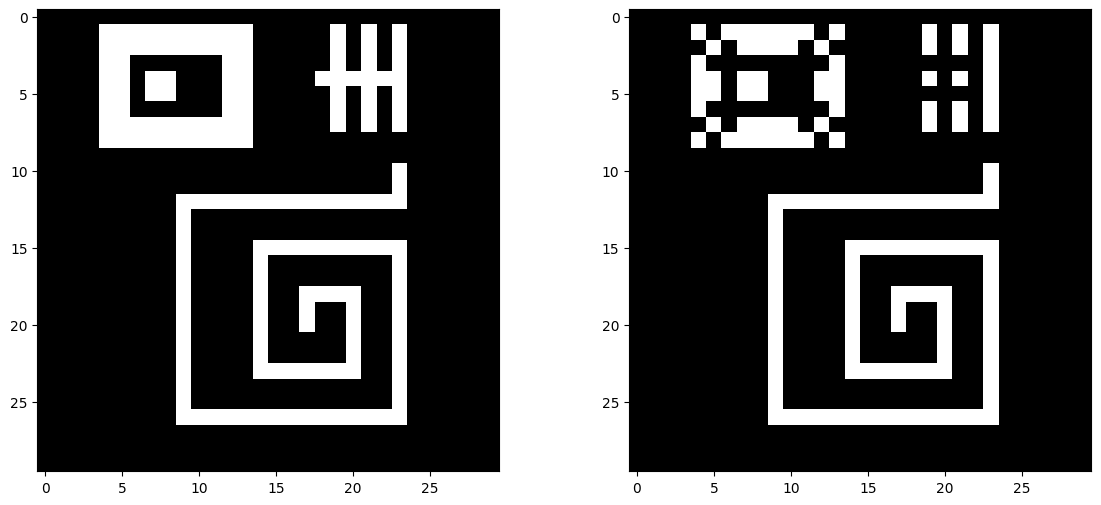

In [31]:
img = read_file('binary1.tiff') / 255
img_n = skeletonizeImage(img)
plot_images(img, img_n)

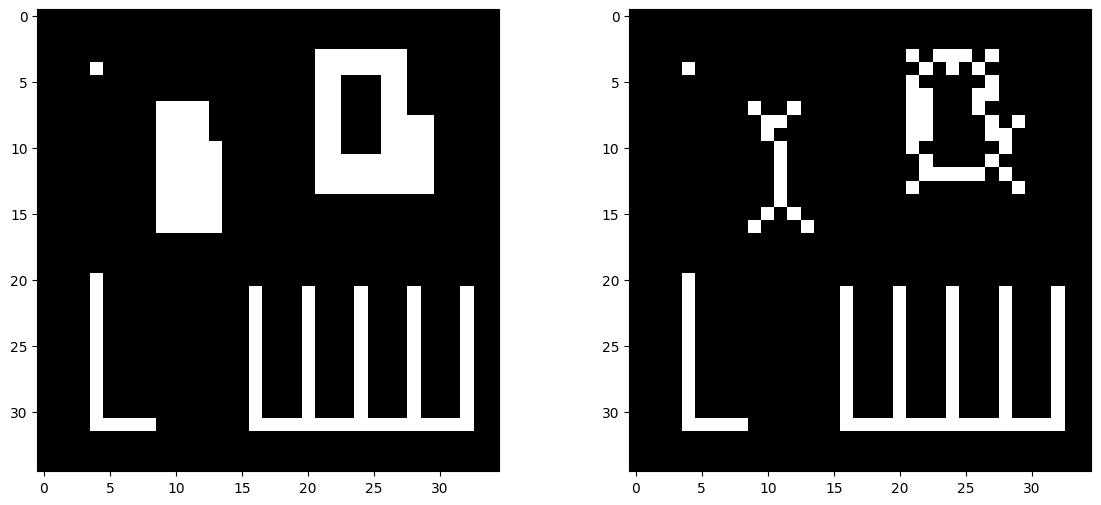

In [32]:
img = read_file('binary2.tiff') / 255
img_n = skeletonizeImage(img)
plot_images(img, img_n)